**1.Getting VizDoom up and running
**

In [1]:
%pip install vizdoom


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
#To work on the alredy predefined environments.
%cd github & git clone https://github.com/mwydmuch/ViZDoom

[WinError 123] The filename, directory name, or volume label syntax is incorrect: 'github & git clone https://github.com/mwydmuch/ViZDoom'
c:\Users\navee\Documents\VizDoom\VizDoom\VizDoom


c:\Users\navee\Envs\RL_ENV\lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [3]:
#import vizdoom for the env
from vizdoom import *

#import random for the action sampling
import random

#import time for sleeping 
import time

#import numpy for identity matrix
import numpy as np

In [4]:
#Game setup
game = DoomGame()   #define the game object
game.load_config('github/VizDoom/scenarios/basic.cfg')  #to load the specific configuratons
game.init()

In [5]:
#This is set the actions we can take in the environment. In this case, we have three actions: move left, move right, and shoot.
actions = np.identity(3,dtype=np.uint8) #create's a 3*3 identity matrix

In [6]:
#matrix of actions
print("left move:",actions[0])

print("right move:",actions[1])
print("attack:",actions[2])


left move: [1 0 0]
right move: [0 1 0]
attack: [0 0 1]


In [7]:
#Random action sampling
random.choice(actions)

array([1, 0, 0], dtype=uint8)

In [8]:
# game.new_episode()
# game.is_episode_finished()
# game.make_action(random.choice(actions))

In [9]:
# state = game.get_state()
# state.screen_buffer  # cotains an numpy array of img 
# info = state.game_variables   #game variable asuch as ammo
# info              #ammo, health, etc.

In [10]:
#Running the game for 5 episodes and taking random actions. these is not trained agent, just random actions to see how the game works.
episodes=2
for episode in range(episodes):
    #create a new episode or game 
    game.new_episode()
    #check the game isn't done
    while not game.is_episode_finished():
        #get the game state
        state = game.get_state()
        #get the game image
        img = state.screen_buffer
        #get the game variable- Ammo
        info = state.game_variables
        #take an action
        reward = game.make_action(random.choice(actions) ,1 ) #helps to skip the frames while visualizing.
        #print reward
        # print('reward :',reward)
        time.sleep(0.02) #time for the break in millli seconds
    print(f'Result: Episode {episode+1}, Total Reward: {game.get_total_reward()}')
    time.sleep(2)



Result: Episode 1, Total Reward: -58.0
Result: Episode 2, Total Reward: -380.0


In [11]:
game.close()

**2.Converting it to the Open Ai Gym wnvironment**

In [12]:
#To visualize the game, we can use OpenCV to display the game screen. We can modify the code to include OpenCV for visualization.
%pip install gym
%pip install opencv-python



Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: opencv-python in c:\users\navee\envs\rl_env\lib\site-packages (4.12.0.88)



You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [13]:
import gymnasium as gym
#import environment base class from the OpenAI gym
from gym import Env
#import gym spaces
from gym.spaces import Discrete,Box
#import opencv
import cv2

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [14]:
#Random action sampling
Discrete(3).sample() #random choice selection
actions[Discrete(3).sample()]

array([0, 0, 1], dtype=uint8)

In [15]:
#Sample a random image from the observation space.
#what is the observation space? it is the screen buffer which is an image of shape (224,224) and pixel values between 0 and 255. so we can sample a random image from this space using the Box space.
Box(low = 0,high=255,shape=(224,224),dtype=np.uint8).sample()

array([[ 56,  63,  90, ...,  79,  38,   2],
       [194, 195, 254, ..., 128, 131,  35],
       [125,  70, 243, ...,  65, 102, 197],
       ...,
       [  4,  89,  22, ..., 218,  66,  56],
       [159,  49, 242, ...,   0, 214, 223],
       [187, 189, 116, ..., 224, 207,  69]], dtype=uint8)

In [16]:
#create a base class VizDoom Environment
class VizDoomGym(Env):
    #Funtion that is called when we call the env
    def __init__(self, render=False):
        #inherit form Env
        super().__init__()
        
        #Game setup
        self.game = DoomGame()
        self.game.load_config('github/VizDoom/scenarios/basic.cfg')  #to load the specific configuratons
        
        
        #Render frame logic
        if render==False:
            self.game.set_window_visible(False)
        else:
            self.game.set_window_visible(True)
            
        self.game.init()
        
        #create an action and observation space
        self.observation_space= Box(low=0,high=255,shape=(100,160,1),dtype=np.uint8)
        self.action_space = Discrete(3)
        
        pass
    
    #this is how we take a step in the environment 
    def step(self,action):
        #Specify action and take step
        actions = np.identity(3,dtype=np.uint8) #create's a 3*3 identity matrix
        reward = self.game.make_action(actions[action],4)
        
        if self.game.get_state():
            state=self.game.get_state().screen_buffer
            state = self.grayscale(state)
            ammo = self.game.get_state().game_variables[0]
            info=ammo
        else:
            state = np.zeros(self.observation_space.shape)
            info =0 
        info={"info":info}
        done = self.game.is_episode_finished()
        
        return state,reward,done,info
    
    #Define how to render the game or environment
    def render(self):
        pass
    
    #What happens when we start a new game
    def reset(self):
        self.game.new_episode()
        state =  self.game.get_state().screen_buffer
        return self.grayscale(state)
        
    
    #Grayscale the game frame and resize it
    def grayscale(self, observation):
        gray = cv2.cvtColor(np.moveaxis(observation,0,-1),cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray,(160,100),interpolation=cv2.INTER_CUBIC)
        state = np.reshape(resize,(100,160,1))
        return state
    
    #Call to close down the game
    def close(self):
        self.game.close()
        pass

**3.View game state
**

In [17]:
#Now we can create an instance of the environment and run it.
env =VizDoomGym(render=True)


In [18]:
#Reset the environment and get the initial state
state=env.reset()


In [19]:
#Take a random action in the environment
env.step(2)

(array([[[55],
         [50],
         [59],
         ...,
         [57],
         [57],
         [66]],
 
        [[68],
         [65],
         [65],
         ...,
         [56],
         [67],
         [72]],
 
        [[49],
         [79],
         [66],
         ...,
         [79],
         [51],
         [29]],
 
        ...,
 
        [[75],
         [63],
         [62],
         ...,
         [44],
         [71],
         [60]],
 
        [[15],
         [48],
         [47],
         ...,
         [49],
         [69],
         [47]],
 
        [[22],
         [14],
         [26],
         ...,
         [57],
         [37],
         [39]]], dtype=uint8),
 -4.0,
 False,
 {'info': np.float64(50.0)})

In [20]:
# #Reset the environment again
# env.reset()

In [21]:
#close the current game
env.close()

In [22]:
# #import Env checker
# from stable_baselines3.common import env_checker
# env_checker.check_env(env, warn=True)

**4. view state
**

In [23]:
%pip install matplotlib

You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [24]:
from matplotlib import pyplot as plt

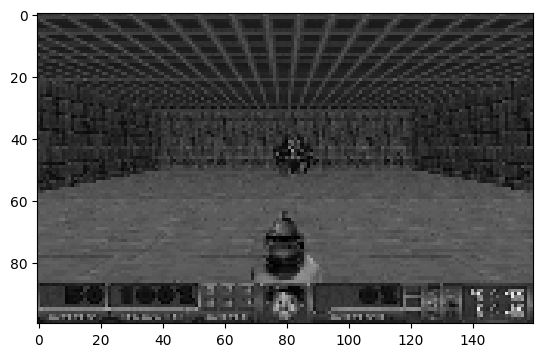

In [25]:
plt.imshow(cv2.cvtColor(state,cv2.COLOR_BGR2RGB))

**5. Set Callback
**

In [26]:
%pip install torch torchvision torchaudio 


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [27]:
%pip install stable-baselines3

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [28]:
#Import os for file navigation and management
import os

#import callback class form sb3. This is used to create custom callbacks for training the agent, such as saving the model at certain intervals or logging training progress.
from stable_baselines3.common.callbacks import BaseCallback


In [29]:
#Custom callback for saving the model at certain intervals during training. This callback will save the model every 'check_freq' steps to the specified 'save_path'.
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.num_timesteps % self.check_freq == 0:
            model_path = os.path.join(
                self.save_path,
                "best_model_{}".format(self.num_timesteps)
            )
            self.model.save(model_path)
            print(f"Saved checkpoint to {model_path}.zip")

        return True

In [30]:
# Directory paths for saving checkpoints and logs
CHECKPOINTS_DIR='./train/train_basic'
LOG_DIR='./logs/log_basic'


In [31]:
#Create an instance of the custom callback
callback=TrainAndLoggingCallback(check_freq=10000,save_path=CHECKPOINTS_DIR)


**6. Train Model
**

In [32]:
#IMPORT PPO FOR TRAININg
from stable_baselines3 import PPO

In [33]:
#non renter environmeant.
env=VizDoomGym()

In [34]:
#log directory for tensorboard and to vizualize the logs.
%pip install shimmy
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [35]:
#Create the PPO model with the specified policy, environment, and training parameters. The model will use a convolutional neural network (CnnPolicy) to process the visual input from the environment. The training logs will be saved to the specified LOG_DIR for visualization in TensorBoard.
model=PPO('CnnPolicy',env,tensorboard_log=LOG_DIR,verbose=1,learning_rate=0.0001,n_steps=2048)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


c:\Users\navee\Envs\RL_ENV\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [38]:
model.learn(total_timesteps=10000, callback=callback, reset_num_timesteps=False)

Logging to ./logs/log_basic\PPO_0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.7     |
|    ep_rew_mean     | -40.2    |
| time/              |          |
|    fps             | 22       |
|    iterations      | 1        |
|    time_elapsed    | 89       |
|    total_timesteps | 14336    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.9        |
|    ep_rew_mean          | -41.3       |
| time/                   |             |
|    fps                  | 14          |
|    iterations           | 2           |
|    time_elapsed         | 285         |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.015863972 |
|    clip_fraction        | 0.206       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.987      |
|    explained_variance   | 0.559     

In [39]:
#activate the env in the command prompt 
#navigate to the ppo and run the command "tensorboard --logdir=." these shows the graph representation of all the selected log. 

**7. Test The Model
**

In [40]:
#import evalution policy to test the model
from stable_baselines3.common.evaluation import evaluate_policy

In [41]:
#reload model from the disc
import os
env = VizDoomGym(render=False)
checkpoints = [f for f in os.listdir(CHECKPOINTS_DIR) if f.startswith('best_model_') and f.endswith('.zip')]
if checkpoints:
    latest = max(checkpoints, key=lambda x: int(x.split('_')[2].split('.')[0]))
    model_path = os.path.join(CHECKPOINTS_DIR, latest)
    model = PPO.load(model_path, env=env)
    print(f"Loaded model from {model_path}")
    
else:
    print("No checkpoints found, creating new model")
    model = PPO('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=1, learning_rate=0.0001, n_steps=2048)


c:\Users\navee\Envs\RL_ENV\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
Loaded model from ./train/train_basic\best_model_40000.zip


In [46]:
#redered the environment
env=VizDoomGym(render=True)

In [68]:
#evaluate mean reward for 20 episodes
mean_reward,_=evaluate_policy(model,env,n_eval_episodes=20)

In [69]:
mean_reward

np.float64(61.5)

In [49]:
for episode in range(5):
    obs =env.reset()
    done= False
    total_reward=0
    while not done:
        action,_ =model.predict(obs)
        obs, reward, done, info =env.step(action)
        time.sleep(0.05)
        total_reward +=reward
    print('Total Reward for episode {} is {}'.format(episode, total_reward))
    time.sleep(2)

Total Reward for episode 0 is 95.0
Total Reward for episode 1 is 95.0
Total Reward for episode 2 is 68.0
Total Reward for episode 3 is 76.0
Total Reward for episode 4 is 76.0
